<a href="https://www.kaggle.com/code/saijeevanbattiprolu/dl-week3?scriptVersionId=297118742" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

### 1. Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv('/kaggle/input/cs1234/Santander Customer Satisfaction_train.csv')
X = data.drop('TARGET', axis=1)
y = data['TARGET']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Scaling (CRITICAL for Perceptron)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

errors = []
train_accuracies = []
test_accuracies = []
weights_norm = []
bias_values = []

for lr in learning_rates:
    perceptron = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=0
    )

    perceptron.fit(X_train, y_train)

    # Predictions
    y_train_pred = perceptron.predict(X_train)
    y_test_pred = perceptron.predict(X_test)

    # Error (loss)
    error = np.mean(y_train_pred != y_train)
    errors.append(error)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Weights & bias
    weights_norm.append(np.linalg.norm(perceptron.coef_))
    bias_values.append(perceptron.intercept_[0])

    print(
        f"LR={lr:<6} | "
        f"Train Acc={train_acc:.4f} | "
        f"Test Acc={test_acc:.4f} | "
        f"Error={error:.4f} | "
        f"||W||={weights_norm[-1]:.3f} | "
        f"Bias={bias_values[-1]:.3f}"
    )


LR=0.0001 | Train Acc=0.9081 | Test Acc=0.9098 | Error=0.0919 | ||W||=0.120 | Bias=-0.030
LR=0.001  | Train Acc=0.9081 | Test Acc=0.9098 | Error=0.0919 | ||W||=1.198 | Bias=-0.300
LR=0.01   | Train Acc=0.9243 | Test Acc=0.9235 | Error=0.0757 | ||W||=12.250 | Bias=-3.010
LR=0.1    | Train Acc=0.9243 | Test Acc=0.9235 | Error=0.0757 | ||W||=122.504 | Bias=-30.100
LR=1.0    | Train Acc=0.9243 | Test Acc=0.9235 | Error=0.0757 | ||W||=1225.044 | Bias=-301.000


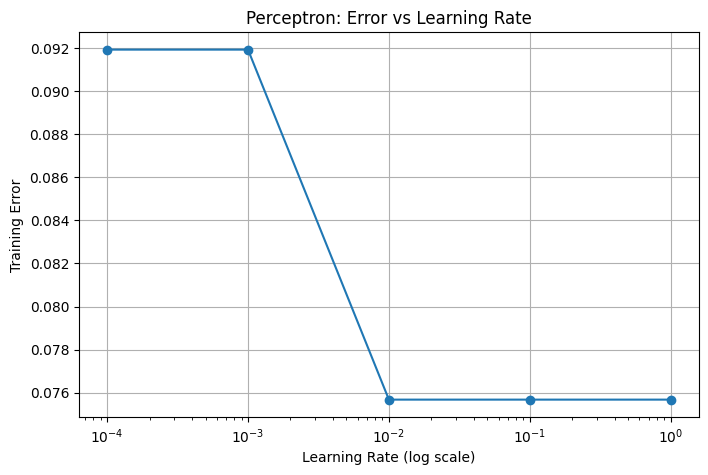

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, errors, marker='o')
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Training Error")
plt.title("Perceptron: Error vs Learning Rate")
plt.grid(True)
plt.show()


### 2.Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
class MLPPerceptron:

    def __init__(self, n_input, n_hidden, n_output, lr=0.01, epochs=5000):
        self.lr = lr
        self.epochs = epochs

        self.W1 = np.random.randn(n_input, n_hidden)
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = np.random.randn(n_hidden, n_output)
        self.b2 = np.zeros((1, n_output))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, X, y):
        losses = []

        for epoch in range(self.epochs):
            # Forward pass
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)

            z2 = np.dot(a1, self.W2) + self.b2
            y_hat = self.sigmoid(z2)

            # Loss (MSE)
            loss = np.mean((y - y_hat) ** 2)
            losses.append(loss)

            # Backpropagation
            delta_output = (y_hat - y) * self.sigmoid_derivative(y_hat)
            delta_hidden = np.dot(delta_output, self.W2.T) * self.sigmoid_derivative(a1)

            # Weight updates
            self.W2 -= self.lr * np.dot(a1.T, delta_output)
            self.b2 -= self.lr * np.sum(delta_output, axis=0, keepdims=True)

            self.W1 -= self.lr * np.dot(X.T, delta_hidden)
            self.b1 -= self.lr * np.sum(delta_hidden, axis=0, keepdims=True)

        return losses

    def predict(self, X):
        a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
        y_hat = self.sigmoid(np.dot(a1, self.W2) + self.b2)
        return (y_hat >= 0.5).astype(int)


In [5]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape labels (CRITICAL)
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
learning_rates = [0.001, 0.01, 0.1]
epochs_list = [100, 50, 10]

results = {}

for lr in learning_rates:
    for epochs in epochs_list:
        print(f"\nTraining with lr={lr}, epochs={epochs}")

        mlp = MLPPerceptron(
            n_input=X_train.shape[1],
            n_hidden=7,
            n_output=1,
            lr=lr,
            epochs=epochs
        )

        losses = mlp.fit(X_train, y_train)
        preds = mlp.predict(X_test)

        accuracy = np.mean(preds == y_test)
        results[(lr, epochs)] = (losses, accuracy)

        print(f"Accuracy: {accuracy:.4f}")



Training with lr=0.001, epochs=100
Accuracy: 0.9474

Training with lr=0.001, epochs=50
Accuracy: 0.9035

Training with lr=0.001, epochs=10
Accuracy: 0.5614

Training with lr=0.01, epochs=100
Accuracy: 0.9737

Training with lr=0.01, epochs=50
Accuracy: 0.9649

Training with lr=0.01, epochs=10
Accuracy: 0.9386

Training with lr=0.1, epochs=100
Accuracy: 0.9825

Training with lr=0.1, epochs=50
Accuracy: 0.9825

Training with lr=0.1, epochs=10
Accuracy: 0.9561


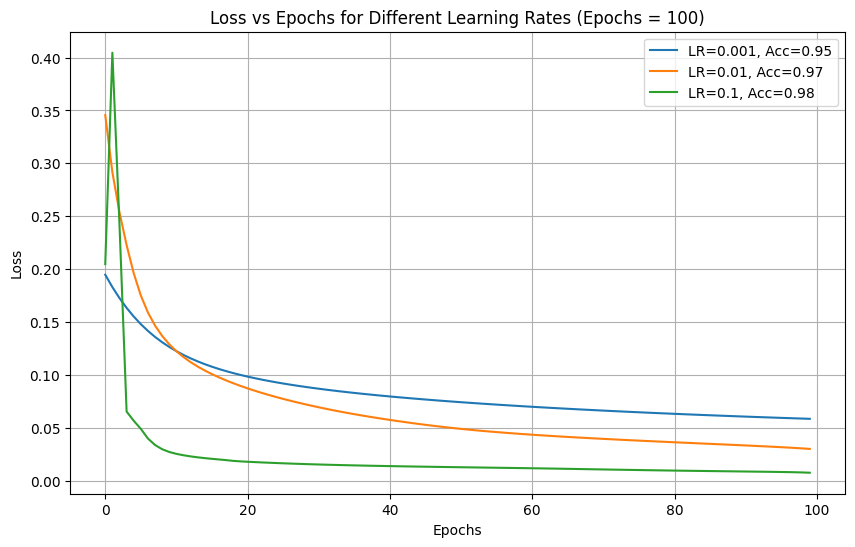

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for (lr, epochs), (losses, acc) in results.items():
    if epochs == 100:   # ✅ must match epochs_list
        plt.plot(
            range(len(losses)),
            losses,
            label=f"LR={lr}, Acc={acc:.2f}"
        )

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs for Different Learning Rates (Epochs = 100)")
plt.legend()
plt.grid(True)
plt.show()


### 3. Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).


In [8]:
from sklearn.datasets import load_iris

# Load IRIS dataset
data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling (IMPORTANT for Perceptron)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

train_accuracies = []
test_accuracies = []

print("Learning Rate Analysis:\n")

for lr in learning_rates:
    perceptron = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        fit_intercept=True,
        shuffle=True,
        random_state=42
    )

    perceptron.fit(X_train, y_train)

    # Predictions
    y_train_pred = perceptron.predict(X_train)
    y_test_pred = perceptron.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"LR={lr:<6} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}")


Learning Rate Analysis:

LR=0.0001 | Train Acc=0.8762 | Test Acc=0.8889
LR=0.001  | Train Acc=0.8762 | Test Acc=0.8889
LR=0.01   | Train Acc=0.8762 | Test Acc=0.8889
LR=0.1    | Train Acc=0.9048 | Test Acc=0.8889
LR=1.0    | Train Acc=0.9048 | Test Acc=0.8889


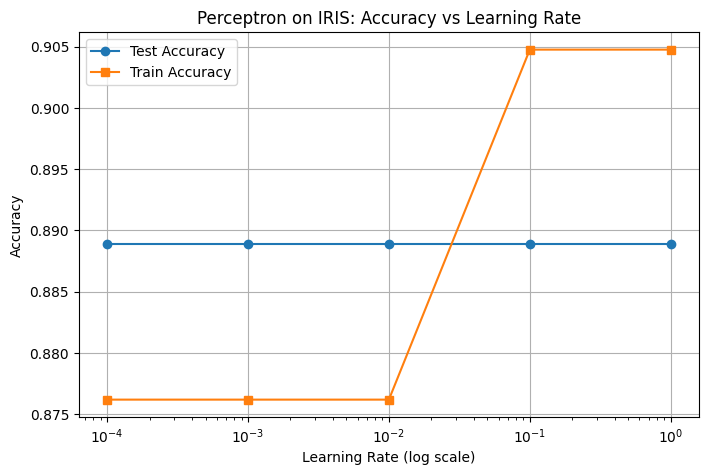

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, test_accuracies, marker='o', label="Test Accuracy")
plt.plot(learning_rates, train_accuracies, marker='s', label="Train Accuracy")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Accuracy")
plt.title("Perceptron on IRIS: Accuracy vs Learning Rate")
plt.legend()
plt.grid(True)
plt.show()


### 4. Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST). 


In [10]:
import numpy as np
import sklearn.datasets as skl_data
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# --- 1. Load MNIST dataset ---
data, labels = skl_data.fetch_openml('mnist_784', version=1, return_X_y=True)

# Convert labels from string to integer
labels = labels.astype(int)

# Normalize pixel values to [0,1]
data = data / 255.0

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# --- 2. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.10, random_state=42, stratify=labels
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# --- 3. Create MLP classifier ---
# Single hidden layer with 175 neurons
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  
    max_iter=200,               
    verbose=1,
    random_state=1
)

# --- 4. Train MLP ---
mlp.fit(X_train, y_train)

# --- 5. Evaluate ---

print("Training set accuracy:", mlp.score(X_train, y_train))
print("Testing set accuracy:", mlp.score(X_test, y_test))

# --- 6. Predict a single digit ---
index = 346
test_digit = X_test.iloc[index].to_numpy().reshape(1, 784)  # use .iloc for row
test_digit_prediction = mlp.predict(test_digit)[0]

print("Predicted value:", test_digit_prediction)
print("Actual value:", y_test.iloc[index])


Data shape: (70000, 784)
Labels shape: (70000,)
X_train shape: (63000, 784)
X_test shape: (7000, 784)
Iteration 1, loss = 0.42565461
Iteration 2, loss = 0.19726882
Iteration 3, loss = 0.14291616
Iteration 4, loss = 0.11261497
Iteration 5, loss = 0.09346874
Iteration 6, loss = 0.07826463
Iteration 7, loss = 0.06785235
Iteration 8, loss = 0.05861600
Iteration 9, loss = 0.05145396
Iteration 10, loss = 0.04482108
Iteration 11, loss = 0.04062207
Iteration 12, loss = 0.03541223
Iteration 13, loss = 0.03153407
Iteration 14, loss = 0.02776332
Iteration 15, loss = 0.02485132
Iteration 16, loss = 0.02206290
Iteration 17, loss = 0.01975107
Iteration 18, loss = 0.01745703
Iteration 19, loss = 0.01587820
Iteration 20, loss = 0.01402050
Iteration 21, loss = 0.01217523
Iteration 22, loss = 0.01129783
Iteration 23, loss = 0.00983355
Iteration 24, loss = 0.00916938
Iteration 25, loss = 0.00783648
Iteration 26, loss = 0.00703042
Iteration 27, loss = 0.00686925
Iteration 28, loss = 0.00592041
Iteration 2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


### 5. Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momemtum, SGD with Nesterov,Adagrad, RMSProp,Adam)

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.utils import to_categorical

# Load dataset (Kaggle path)
DATASET_PATH = "/kaggle/input/diabetes-data-set/diabetes.csv"
data = pd.read_csv(DATASET_PATH)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encoding
y = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MLP model
def create_mlp():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(y_train.shape[1], activation='softmax'))
    return model

2026-02-11 09:15:11.747980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770801311.933648      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770801311.987010      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770801312.436807      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770801312.436831      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770801312.436833      24 computation_placer.cc:177] computation placer alr

#### Batch Gradient Descent (BGD)

In [12]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=len(X_train)   # FULL dataset
)

model.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770801324.295871      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770801324.301621      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1770801325.961472      70 service.cc:152] XLA service 0x7e5bd8004ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770801325.961505      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770801325.961508      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770801326.128191      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6612 - loss: 0.6468
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6612 - loss: 0.6450
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6645 - loss: 0.6433
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6645 - loss: 0.6417
Epoch 5/30


I0000 00:00:1770801327.050757      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6661 - loss: 0.6400
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6661 - loss: 0.6384
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6645 - loss: 0.6369
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6645 - loss: 0.6353
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6629 - loss: 0.6338
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6661 - loss: 0.6323
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6661 - loss: 0.6309
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6645 - loss: 0.6294
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6678 - loss: 0.6280
Epoch 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6694 - loss: 0.6266
Epoch 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6678 - loss: 0.6253
Epoch 16/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6678 - loss: 0.6239
Epoch 17

[0.5992794036865234, 0.7532467246055603]

#### Stochastic Gradient Descent (SGD)

In [13]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=1   # ONE sample
)

model.evaluate(X_test, y_test)

Epoch 1/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6440 - loss: 0.5952
Epoch 2/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8146 - loss: 0.4591
Epoch 3/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7673 - loss: 0.4739
Epoch 4/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7787 - loss: 0.4318
Epoch 5/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7875 - loss: 0.4434
Epoch 6/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8423 - loss: 0.3880
Epoch 7/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7562 - loss: 0.4306
Epoch 8/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8231 - loss: 0.3721
Epoch 9/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.3709
Epoch 10/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7831 - loss: 0.4194
Epoch 11/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8009 - loss: 0.4281
Epoch 12/30
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

[0.7395481467247009, 0.7337662577629089]

#### Mini-Batch Gradient Descent

In [14]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3032 - loss: 0.7801
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5162 - loss: 0.7126 
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6379 - loss: 0.6606 
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6306 - loss: 0.6443 
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6890 - loss: 0.6064 
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6844 - loss: 0.5983 
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6768 - loss: 0.5890 
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7126 - loss: 0.5688 
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7359 - loss: 0.5392 
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7564 - loss: 0.5207 
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7543 - loss: 0.5172 
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

[0.5090912580490112, 0.7467532753944397]

#### SGD with Momentum

In [15]:
model = create_mlp()

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5099 - loss: 0.7116
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7179 - loss: 0.5516 
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8017 - loss: 0.4740 
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7670 - loss: 0.4772 
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7837 - loss: 0.4472 
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7879 - loss: 0.4388 
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7873 - loss: 0.4296 
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7988 - loss: 0.4401 
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8047 - loss: 0.4003 
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8167 - loss: 0.4063 
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7912 - loss: 0.4203 
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

[0.5704662799835205, 0.7532467246055603]

#### SGD with Nesterov Momentum

In [16]:
model = create_mlp()

model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32
)

model.evaluate(X_test, y_test)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6125 - loss: 0.6632
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7343 - loss: 0.5403 
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7879 - loss: 0.4657 
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7827 - loss: 0.4633 
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4389 
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7786 - loss: 0.4463 
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4326 
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8068 - loss: 0.4020 
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7921 - loss: 0.4152 
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7847 - loss: 0.4331 
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7627 - loss: 0.4499 
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 

[0.5762156248092651, 0.7337662577629089]